In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error,mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score,precision_score,recall_score,\
    f1_score ,confusion_matrix,classification_report,roc_curve,auc
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
data=pd.read_csv(r'C:\creativa_datasets\cars_data.csv')

In [41]:
data.head()

,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1,6451.0


| **العمود**          | **الوصف**                                                                                      |
| ------------------- | ---------------------------------------------------------------------------------------------- |
| **Brand**           | ماركة السيارة، مثل: Toyota، BMW، Ford، Honda.                                                  |
| **Year**            | سنة تصنيع السيارة، وتوضح عمر السيارة.                                                          |
| **Mileage**         | عدد الكيلومترات التي قطعتها السيارة منذ استخدامها.                                             |
| **Engine_Size**     | سعة المحرك (باللتر)، مثل 1.6 أو 2.0 لتر.                                                       |
| **Fuel_Type**       | نوع الوقود المستخدم، مثل: بنزين (Petrol)، ديزل (Diesel)، هجين (Hybrid)، أو كهربائي (Electric). |
| **Transmission**    | نوع ناقل الحركة (الفتيس)، مثل: أوتوماتيك (Automatic) أو يدوي (Manual).                         |
| **Previous_Owners** | عدد الملاك السابقين للسيارة قبل المالك الحالي.                                                 |
| **Price**           | سعر السيارة، وهو المتغير المستهدف (Target) في حالة بناء نموذج للتنبؤ بالأسعار.                 |


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            979 non-null    object 
 1   Year             974 non-null    float64
 2   Mileage          979 non-null    float64
 3   Engine_Size      964 non-null    float64
 4   Fuel_Type        982 non-null    object 
 5   Transmission     962 non-null    object 
 6   Previous_Owners  950 non-null    object 
 7   Price            987 non-null    float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [43]:
data.isna().sum()

Brand              21
Year               26
Mileage            21
Engine_Size        36
Fuel_Type          18
Transmission       38
Previous_Owners    50
Price              13
dtype: int64

In [44]:
data.duplicated().sum()

0

In [45]:
data.shape

(1000, 8)

In [46]:
data.dropna(subset=['Price'], inplace=True)

In [47]:
data.isna().sum()

Brand              21
Year               20
Mileage            15
Engine_Size        30
Fuel_Type          12
Transmission       25
Previous_Owners    42
Price               0
dtype: int64

IMPUTER

In [49]:
data['Previous_Owners'] = pd.to_numeric(data['Previous_Owners'], errors='coerce')

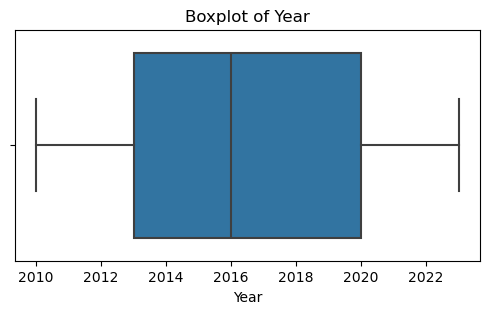

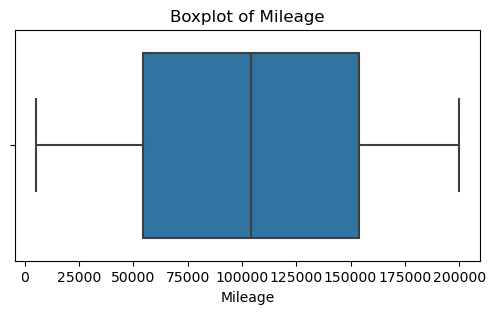

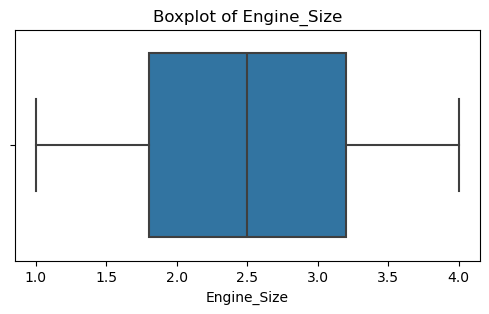

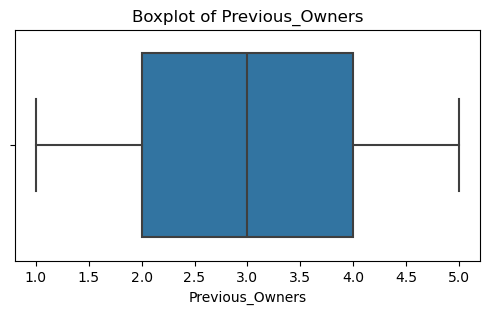

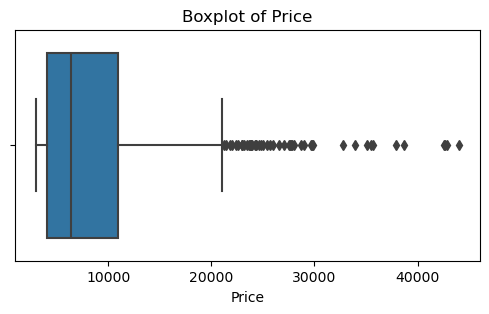

In [57]:
#checking for outliers in numerical columns using boxplots
numoutlier_cols = ['Year', 'Mileage', 'Engine_Size', 'Previous_Owners', 'Price']

for col in numoutlier_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [51]:
from sklearn.impute import SimpleImputer

num_cols = ['Year', 'Mileage', 'Engine_Size', 'Previous_Owners']

cat_cols = ['Brand', 'Fuel_Type', 'Transmission']

In [53]:
num_imputer = SimpleImputer(strategy='mean')
data[num_cols] = num_imputer.fit_transform(data[num_cols])

In [54]:
cat_imputer = SimpleImputer(strategy='most_frequent')
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

In [55]:
data.isna().sum()

Brand              0
Year               0
Mileage            0
Engine_Size        0
Fuel_Type          0
Transmission       0
Previous_Owners    0
Price              0
dtype: int64

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 987 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            987 non-null    object 
 1   Year             987 non-null    float64
 2   Mileage          987 non-null    float64
 3   Engine_Size      987 non-null    float64
 4   Fuel_Type        987 non-null    object 
 5   Transmission     987 non-null    object 
 6   Previous_Owners  987 non-null    float64
 7   Price            987 non-null    float64
dtypes: float64(5), object(3)
memory usage: 69.4+ KB


In [59]:
#because label encoding is not suitable for nominal categorical, it is more suitable for ordinal variables,
# so we will use one-hot encoding for the categorical columns.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform
encoded_data = encoder.fit_transform(data[cat_cols])

# Convert to a DataFrame
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(cat_cols),
    index=data.index
)

# Drop the original categorical columns and concatenate the encoded columns
data = pd.concat([data.drop(columns=cat_cols), encoded_df], axis=1)

# View the result
print(data.head())

     Year   Mileage  Engine_Size  Previous_Owners   Price  Brand_BMW  \
0  2015.0  110373.0          2.5         2.000000  3000.0        0.0   
1  2010.0  186144.0          1.3         5.000000  4844.0        0.0   
2  2018.0   29574.0          2.6         1.000000  6628.0        0.0   
3  2010.0  139502.0          2.4         3.045551  3000.0        0.0   
4  2014.0  148748.0          3.5         1.000000  6451.0        1.0   

   Brand_Honda  Brand_Hyundai  Brand_Kia  Brand_Mazda  Brand_Mercedes  \
0          0.0            0.0        1.0          0.0             0.0   
1          0.0            0.0        0.0          0.0             1.0   
2          0.0            0.0        0.0          0.0             0.0   
3          0.0            0.0        1.0          0.0             0.0   
4          0.0            0.0        0.0          0.0             0.0   

   Brand_Nissan  Brand_Toyota  Fuel_Type_Diesel  Fuel_Type_Electric  \
0           0.0           0.0               0.0          

In [60]:
# scaling since we are using KNN
#we do the scaling after the one-hot encoding and train-test split to avoid data leakage.

X = data.drop('Price', axis=1)
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

# 3. Scale ONLY the training data
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 4. Use the same scaler on the test data
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [91]:
#to find best k in KNN regression we can use grid search or cross-validation, but for simplicity, we will start with k=5.

knn = KNeighborsRegressor(n_neighbors=4)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [63]:
#grid search for best k in KNN regression

from sklearn.model_selection import GridSearchCV

# Create the model
knn = KNeighborsRegressor()

# Values of k to test
param_grid = {
    'n_neighbors': range(1, 21)
}

# Grid Search
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Fit on the training data
grid_search.fit(X_train, y_train)

# Best k
print("Best k:", grid_search.best_params_['n_neighbors'])

# Best model
best_knn = grid_search.best_estimator_

# Predictions
y_pred = best_knn.predict(X_test)

Best k: 4


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))  #the bigger the better, 1 is perfect prediction, 0 means the model is no better than predicting the mean of the target variable

MAE: 2321.40404040404
RMSE: 3579.0133568604992
R²: 0.7173114796796536


In [77]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head(10))

      Actual  Predicted
322  13086.0   14279.75
139   7063.0    6286.25
512   5570.0    5776.00
867   8001.0   12097.50
88   24785.0   14769.25
411  15241.0   11606.50
918   9103.0    6955.75
107  11221.0    9717.50
59    3000.0    3000.00
547  20073.0   21329.00


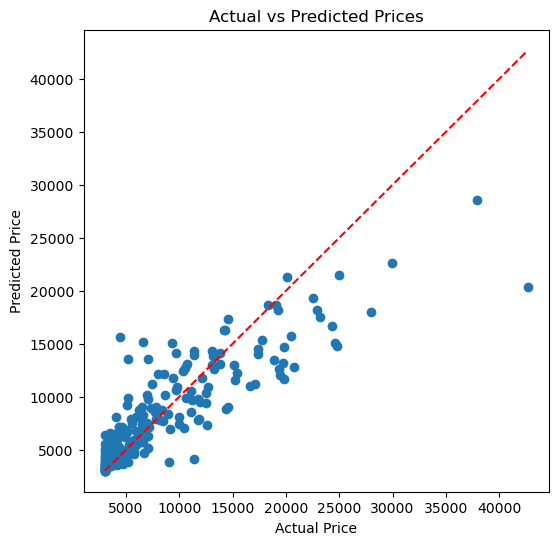

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.show()

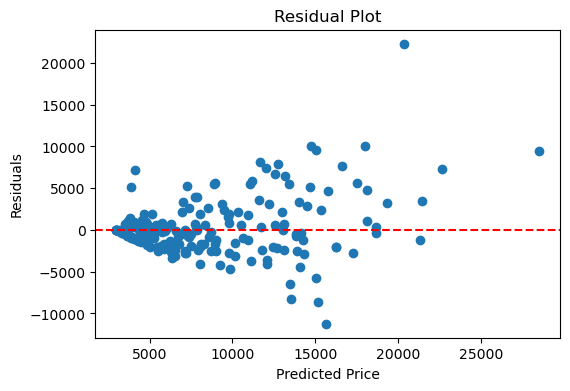

In [79]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Linear Regression

In [85]:
# trying linear regression to see if it performs better than KNN regression
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train, y_train)

y_pred_lr = linear.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²:", r2_score(y_test, y_pred_lr))  #the bigger the better, 1 is perfect prediction, 0 means the model is no better than predicting the mean of the target variable

MAE: 2326.7547881617156
RMSE: 3474.7112697338594
R²: 0.733548002760215


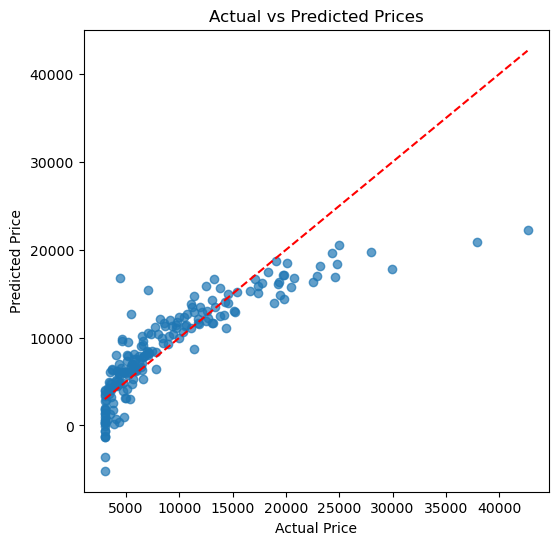

In [87]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

Random forest

the best model

In [86]:
#slightly better
#trying random forest regression 
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))

MAE: 1783.7105050505054
RMSE: 3222.9628136493707
R²: 0.7707590900863719


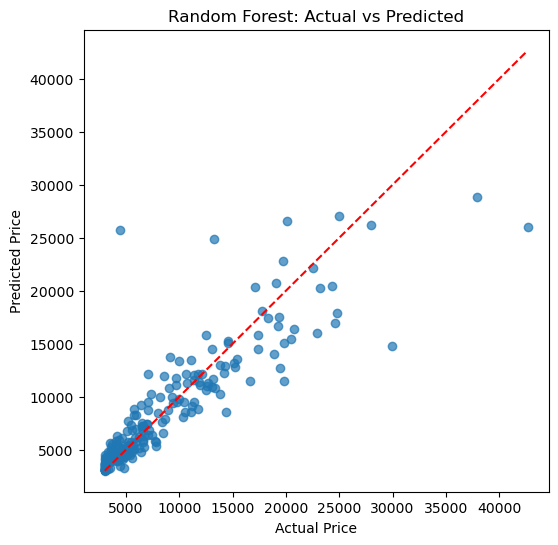

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted")
plt.show()